# Galaxy Redshift Prediction with AlexNet



## 1. Setup 

In [6]:
import os
import sys
import csv
import copy

project_root = os.path.abspath("../")
sys.path.insert(0, project_root)

import h5py
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
from torchvision import models
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, SequentialLR, LinearLR
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src.data_loader import get_dataloaders, BAND_MEAN, BAND_STD
from src.metrics import redshift_metrics, evaluate_by_bin
from src.utils import (set_seed, get_device, SPLIT_COLORS,
                       plot_pred_vs_true, plot_binned_performance,
                       full_evaluation, full_evaluation_extended,
                       plot_learning_curves)
from src.models.alexnet import AlexNetRegressor

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
set_seed(42)
device = get_device()

Using MPS (Apple Metal GPU)


## 2. Data 

In [ ]:
BASE_DATA = os.path.abspath("../data/")
BASE_MODELS = os.path.abspath("../models/")
BASE_REPORTS = os.path.abspath("../reports/")
os.makedirs(BASE_MODELS, exist_ok=True)

TRAIN_PATH = os.path.join(BASE_DATA, "5x127x127_training_with_morphology.hdf5")
VAL_PATH = os.path.join(BASE_DATA, "5x127x127_validation_with_morphology.hdf5")
TEST_PATH = os.path.join(BASE_DATA, "5x127x127_testing_with_morphology.hdf5")

EXCLUDE = {"image", "specz_redshift", "specz_redshift_err", "specz_flag_homogeneous"}

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_path=TRAIN_PATH,
    val_path=VAL_PATH,
    test_path=TEST_PATH,
    batch_size=64,
    num_workers=0,
)

imgs, labels = next(iter(train_loader))
print(f"images: {imgs.shape} | dtype: {imgs.dtype} | NaN: {imgs.isnan().any().item()}")
print(f"labels: min={labels.min():.3f}  max={labels.max():.3f}  mean={labels.mean():.3f}")
print(f"per-band mean: {imgs.mean(dim=[0, 2, 3]).numpy().round(3)}")
print(f"per-band std: {imgs.std(dim=[0, 2, 3]).numpy().round(3)}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples
images : torch.Size([64, 5, 127, 127]) | dtype: torch.float32 | NaN: False
labels : min=0.045  max=2.756  mean=0.588
per-band mean: [0.017 0.018 0.025 0.02  0.019]
per-band std : [0.76  0.865 1.122 0.995 0.941]


## 3. Model

AlexNet with a first convolution adapted to 5-band input (5→64 channels) and a 4-layer SiLU MLP regression head replacing the original classifier.

In [ ]:
SAVE_PATH = os.path.join(BASE_MODELS, "alexnet_best.pth")
RESUME_PATH = os.path.join(BASE_MODELS, "alexnet_latest.pth")
NUM_EPOCHS = 50
patience = 15

model = AlexNetRegressor(in_channels=5, freeze_backbone=False).to(device)
criterion = nn.SmoothL1Loss(beta=0.1)

optimizer = optim.AdamW([
    {"params": model.features.parameters(), "lr": 1e-5},
    {"params": model.head.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=45, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

scaler = torch.amp.GradScaler() if str(device) == "cuda" else None

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device          : {device}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Loss            : SmoothL1Loss(beta=0.1)")
print(f"Scheduler       : LinearWarmup(5) → CosineAnnealing(45) eta_min=1e-6")
print(f"LR backbone     : 1e-5  |  LR head: 1e-3")
print(f"Mixed precision : {'enabled (GradScaler)' if scaler else 'disabled'}")
print(f"Save path       : {SAVE_PATH}")

Device          : mps
Total params    : 4,747,201
Trainable params: 4,747,201
Loss            : SmoothL1Loss(beta=0.1)
Scheduler       : LinearWarmup(5) → CosineAnnealing(45) eta_min=1e-6
LR backbone     : 1e-5  |  LR head: 1e-3
Mixed precision : disabled
Save path       : /Users/arpinejanunts/Desktop/Capstone/models/alexnet_best.pth


## 4. Training 


In [ ]:
def train_epoch(model, loader, optim, criterion, device, scaler=None, accum=2):
    model.train()
    total_loss, running_loss = 0.0, 0.0
    pbar = tqdm(loader, desc="Train", leave=True)
    optim.zero_grad(set_to_none=True)
    autocast_device = "cuda" if str(device) == "cuda" else "cpu"

    for i, (imgs, targets) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).squeeze()

        if model.training:
            if torch.rand(1).item() > 0.5:
                imgs = TF.hflip(imgs)
            if torch.rand(1).item() > 0.5:
                imgs = TF.vflip(imgs)
            angle = int(torch.randint(0, 4, (1,)).item()) * 90
            imgs = TF.rotate(imgs, angle)

        with torch.amp.autocast(autocast_device, enabled=scaler is not None):
            preds = model(imgs)
            loss = criterion(preds, targets) / accum

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (i + 1) % accum == 0:
            if scaler:
                scaler.unscale_(optim)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optim)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
            optim.zero_grad(set_to_none=True)

        batch_loss = loss.item() * accum
        total_loss += batch_loss
        running_loss = total_loss / (i + 1)
        gpu_gb = f"{torch.cuda.memory_allocated(device)/1e9:.1f}" if str(device) == "cuda" else "N/A"
        pbar.set_postfix({
            "batch_loss": f"{batch_loss:.4f}",
            "avg_loss" : f"{running_loss:.4f}",
            "best_val" : f"{best_loss:.4f}" if "best_loss" in globals() else "N/A",
            "lr" : f"{optim.param_groups[0]['lr']:.1e}",
            "GPU_GB" : gpu_gb,
        })

    if (i + 1) % accum != 0:
        if scaler:
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optim)
            scaler.update()
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
        optim.zero_grad(set_to_none=True)

    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).reshape(-1)
            preds = model(imgs)
            loss = criterion(preds, targets)
            total_loss += loss.item() * imgs.size(0)
            all_preds.append(preds.cpu().float().numpy())
            all_targets.append(targets.cpu().float().numpy())

    y_pred = np.concatenate(all_preds).flatten()
    y_true = np.concatenate(all_targets).flatten()
    metrics = redshift_metrics(y_pred, y_true)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


In [9]:
start_epoch = 0
train_losses = []
val_losses = []
best_loss = float("inf")
no_improve = 0

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if "scaler_state_dict" in ckpt and scaler and ckpt["scaler_state_dict"]:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt.get("epoch", 0) + 1
    best_loss = ckpt.get("best_val_loss", float("inf"))
    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    no_improve = ckpt.get("no_improve", 0)
    print(f"Resumed epoch {start_epoch}, best: {best_loss:.4f}, no_improve: {no_improve}")

checkpoint_template = {
    "model_params"    : {
        "in_channels" : 5,
        "latent_dim" : 256,
        "backbone" : "alexnet_pretrained",
        "pool" : "AdaptiveAvgPool2d(4,4)",
        "head" : "Linear(4096→512→256→128→1) SiLU+Dropout(0.4,0.3)",
        "freeze_backbone": False,
        "weight_init" : "kaiming_normal + ImageNet RGB transfer",
    },
    "mean" : BAND_MEAN.tolist() if hasattr(BAND_MEAN, "tolist") else list(BAND_MEAN),
    "std" : BAND_STD.tolist() if hasattr(BAND_STD, "tolist") else list(BAND_STD),
    "batch_size" : 64,
    "criterion" : "SmoothL1Loss(beta=0.1)",
    "task" : "redshift_regression",
    "torch_version" : torch.__version__,
    "optimizer_config": {
        "backbone_lr" : 1e-5,
        "head_lr" : 1e-3,
        "weight_decay": 1e-4,
        "eta_min" : 1e-6,
        "T_max" : 45,
        "warmup_epochs": 5,
        "patience" : patience,
        "accum_steps" : 2,
    },
}

CSV_PATH = os.path.join(BASE_MODELS, "alexnet_training_metrics.csv")
if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow([
            "epoch", "train_loss", "val_loss", "val_mae", "val_rmse",
            "val_r2", "val_nmad", "val_outlier_pct",
            "within_0.1z", "within_0.05z", "val_bias",
            "gap", "best_val_loss", "no_improve", "is_best", "lr"
        ])

print(f"Training from epoch {start_epoch}/{NUM_EPOCHS}")

Resumed epoch 50, best: 0.0635, no_improve: 1
Training from epoch 50/50


In [10]:
for epoch in range(start_epoch, NUM_EPOCHS):
    tr_loss = train_epoch(model, train_loader, optimizer, criterion, device, scaler)
    val_metrics = evaluate(model, val_loader, criterion, device)
    val_loss = val_metrics["loss"]
    current_lr = optimizer.param_groups[0]["lr"]
    gap = tr_loss - val_loss
    gap_str = f"+{gap:.4f}" if gap >= 0 else f"{gap:.4f}"

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step()

    is_best = val_loss < best_loss * 0.999

    latest_ckpt = copy.deepcopy(checkpoint_template)
    latest_ckpt.update({
        "model_state_dict" : model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict" : scaler.state_dict() if scaler else {},
        "epoch" : epoch,
        "best_val_loss" : best_loss,
        "no_improve" : no_improve,
        "train_losses" : train_losses.copy(),
        "val_losses" : val_losses.copy(),
    })
    torch.save(latest_ckpt, RESUME_PATH)

    with open(CSV_PATH, "a", newline="") as f:
        csv.writer(f).writerow([
            epoch + 1,
            round(tr_loss, 6),
            round(val_loss, 6),
            round(val_metrics["mae"], 6),
            round(val_metrics["rmse"], 6),
            round(val_metrics["r2"], 6),
            round(val_metrics["nmad"], 6),
            round(val_metrics["outlier_pct"], 4),
            round(val_metrics["within_0.1z"], 4),
            round(val_metrics["within_0.05z"], 4),
            round(val_metrics["bias"], 6),
            round(gap, 6),
            round(best_loss, 6),
            no_improve,
            is_best,
            current_lr,
        ])

    clear_output(wait=True)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, "b-", label="Train")
    plt.plot(val_losses, "r-", label="Val")
    plt.yscale("log"); plt.legend()
    plt.title(f"Epoch {epoch+1}  Best {best_loss:.4f}"); plt.grid()
    plt.subplot(1, 2, 2)
    for iy, (k, v) in enumerate(val_metrics.items()):
        plt.text(0.1, 0.9 - iy * 0.12, f"{k}: {v:.4f}", fontsize=11)
    plt.text(0.1, 0.9 - len(val_metrics) * 0.12,
             f"No improve: {no_improve}/{patience}", fontsize=11)
    plt.text(0.1, 0.9 - (len(val_metrics) + 1) * 0.12,
             f"LR: {current_lr:.2e}", fontsize=11)
    plt.axis("off"); plt.tight_layout(); plt.show()

    print(f"Epoch {epoch+1}  Train {tr_loss:.4f}  Val {val_loss:.4f}  Gap {gap_str}  "
          f"MAE {val_metrics['mae']:.4f}  NMAD {val_metrics['nmad']:.4f}  "
          f"Outlier {val_metrics['outlier_pct']:.2f}%  R2 {val_metrics['r2']:.4f}  "
          f"LR {current_lr:.2e}")

    if is_best:
        best_loss = val_loss
        no_improve = 0
        best_ckpt = copy.deepcopy(checkpoint_template)
        best_ckpt.update({
            "model_state_dict" : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict" : scaler.state_dict() if scaler else {},
            "epoch" : epoch,
            "best_val_loss" : best_loss,
            "no_improve" : no_improve,
            "train_losses" : train_losses.copy(),
            "val_losses" : val_losses.copy(),
        })
        torch.save(best_ckpt, SAVE_PATH)
        print(f"  ★ Best model saved (val_loss={best_loss:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Training complete!")

Training complete!


## 5. Evaluation

In [12]:
inference_device = torch.device("cpu")
model.to(inference_device)

ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']+1} (val loss: {ckpt['best_val_loss']:.4f})")

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, targets in tqdm(test_loader, desc="Test inference"):
        preds = model(imgs.to(inference_device)).cpu().float().numpy()
        all_preds.append(preds)
        all_targets.append(targets.numpy())

y_pred = np.concatenate(all_preds).flatten()
y_true = np.concatenate(all_targets).flatten()

mask_primary = (y_true >= 0.0) & (y_true <= 2.5)
y_pred_primary = y_pred[mask_primary]
y_true_primary = y_true[mask_primary]

print(f"\n=== Primary range (0.0 ≤ z ≤ 2.5) — N={mask_primary.sum():,} ===")
test_metrics = redshift_metrics(y_pred_primary, y_true_primary)
for key, value in test_metrics.items():
    print(f"  {key:<28}: {value:.4f}")

evaluate_by_bin(y_true_primary, y_pred_primary,
                bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

Loaded best model from epoch 50 (val loss: 0.0634)


Test inference:   0%|          | 0/640 [00:00<?, ?it/s]


=== Primary range (0.0 ≤ z ≤ 2.5) — N=40,039 ===
  rmse                        : 0.1889
  mae                         : 0.0783
  bias                        : 0.0133
  r2                          : 0.8229
  nmad                        : 0.0307
  outlier_pct                 : 4.9202
  cat_outlier_pct             : 2.0080
  three_sigma_outlier_pct     : 8.9912
  outlier_abs_pct             : 0.9890
  lsst_cat_outlier_pct        : 0.9890
  within_0.1z                 : 0.9179
  within_0.05z                : 0.7870

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.1322   0.0240      2.91%       0.40%   0.0139
0.5–1.0       14,815   0.1813   0.0267      3.98%       1.06%   0.0029
1.0–1.5        2,069   0.3759   0.0868     19.72%       3.38%  -0.0268
1.5–2.0          938   0.4241   0.1142     28.46%       4.48%   0.0070
2.0–2.5        1,047   0.4395   0.0701     15.38%       5

,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.132192,0.024044,2.910200,0.401885,0.013857
1,0.5–1.0,14815,0.181282,0.026696,3.975700,1.059737,0.002859
2,1.0–1.5,2069,0.375856,0.086786,19.719671,3.383277,-0.026785
3,1.5–2.0,938,0.424113,0.114196,28.464819,4.477612,0.006995
4,2.0–2.5,1047,0.439495,0.070149,15.377268,5.921681,-0.022552


In [19]:
np.save(os.path.join(BASE_MODELS, "alexnet_ypred.npy"), y_pred_primary)
np.save(os.path.join(BASE_MODELS, "alexnet_ytrue.npy"), y_true_primary)

## 6. Model Visualizations

Scatter plot saved → /Users/arpinejanunts/Desktop/Capstone/reports/alexnet_scatter.png


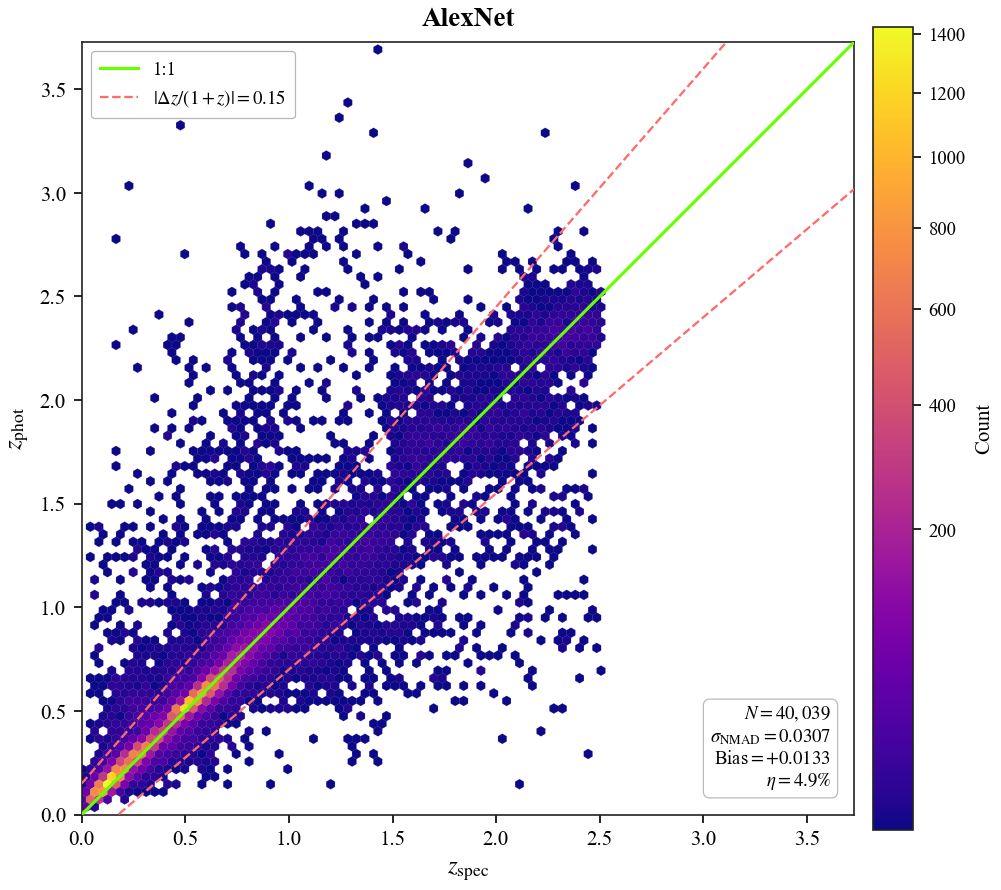

In [20]:
plot_pred_vs_true(
    y_true_primary,
    y_pred_primary,
    name="AlexNet",
    save_path=os.path.join(BASE_REPORTS, "alexnet_scatter.png"),
)

Binned performance saved → /Users/arpinejanunts/Desktop/Capstone/reports/alexnet_binned.png


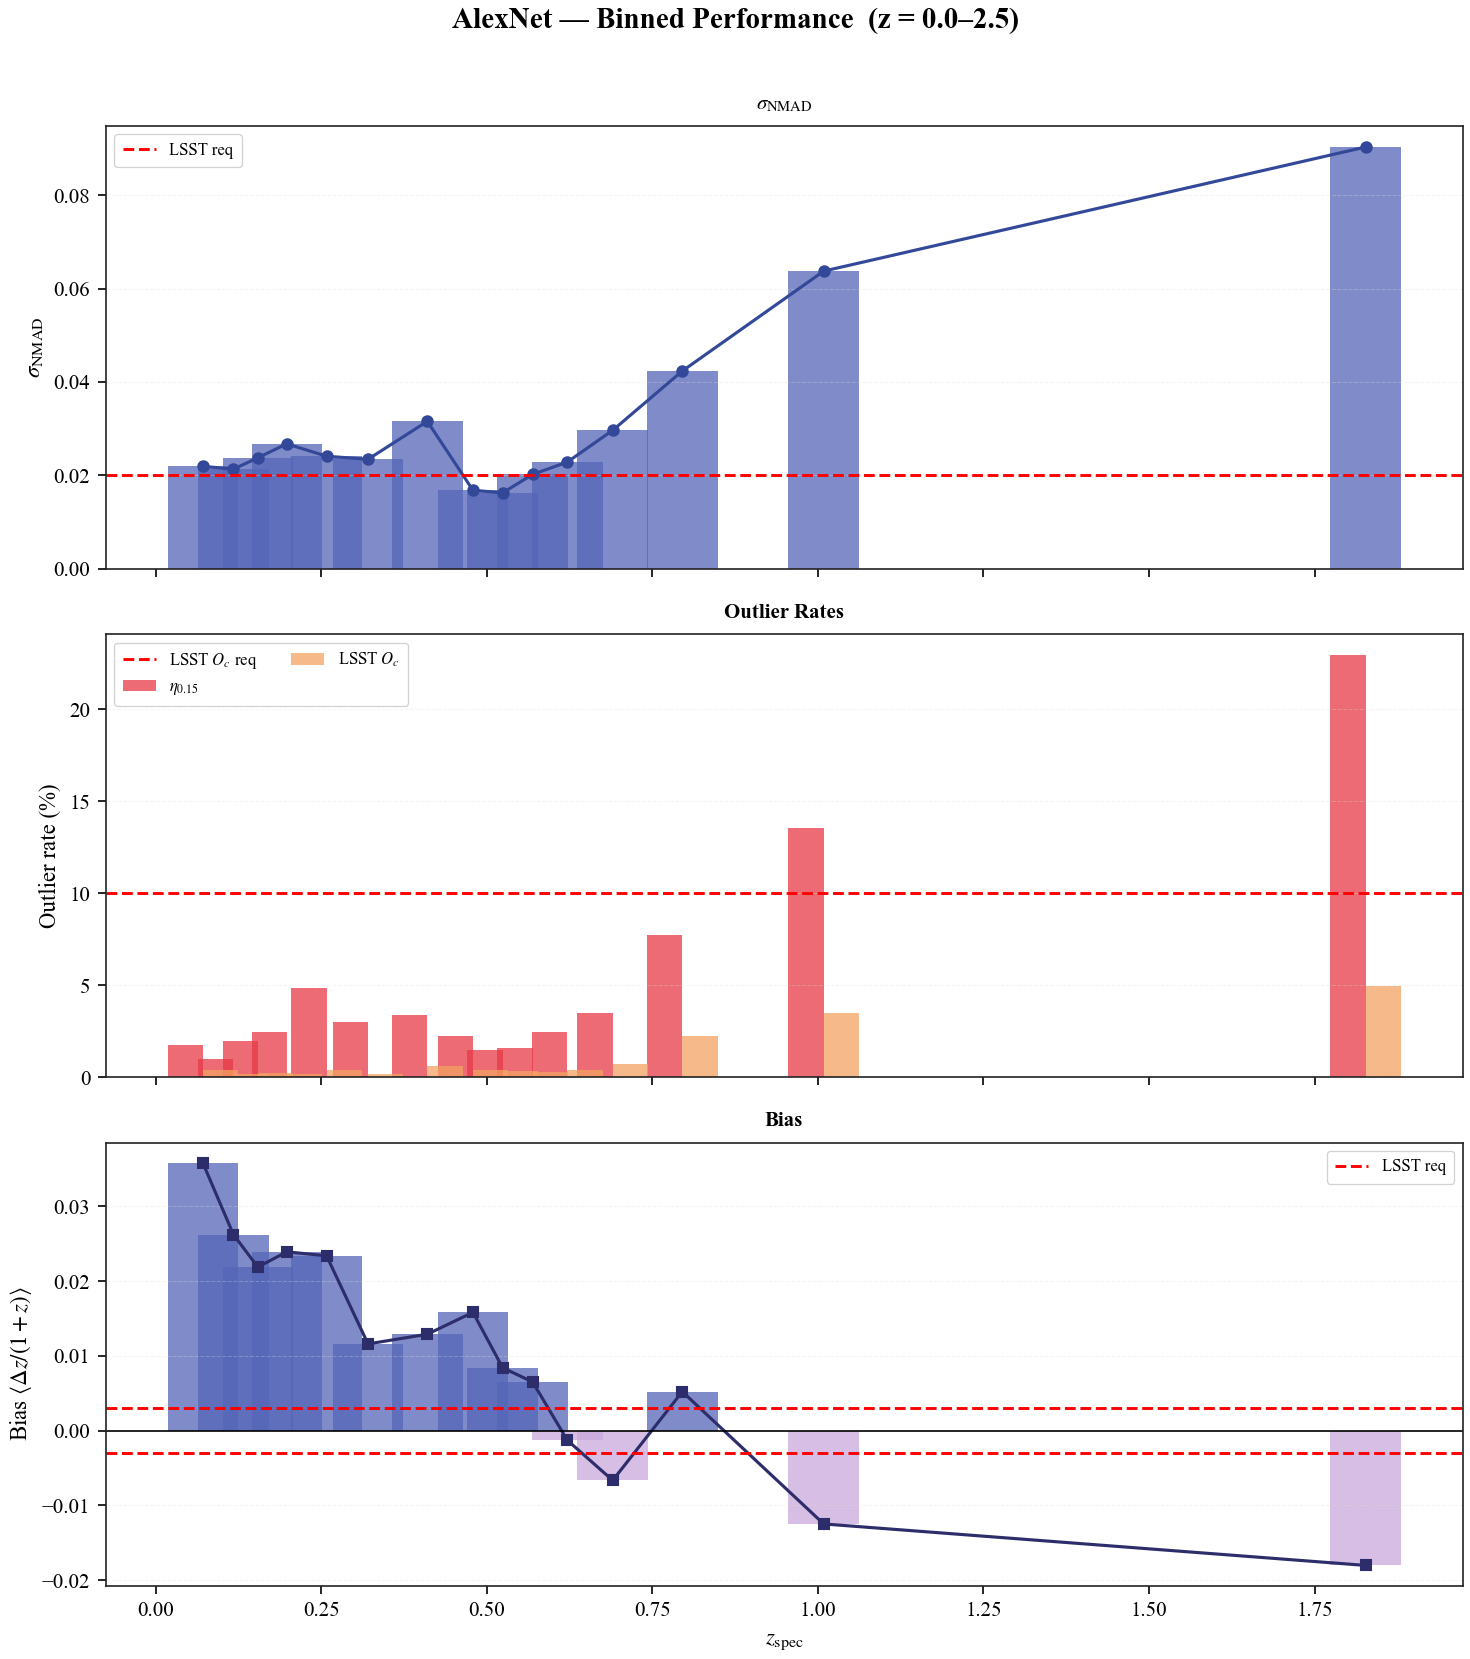

In [21]:
plot_binned_performance(
    y_true_primary,
    y_pred_primary,
    name="AlexNet",
    n_bins=15,
    z_range=(0.0, 2.5),
    save_path=os.path.join(BASE_REPORTS, "alexnet_binned.png"),
)

Figure saved → /Users/arpinejanunts/Desktop/Capstone/reports/alexnet_full_eval.png


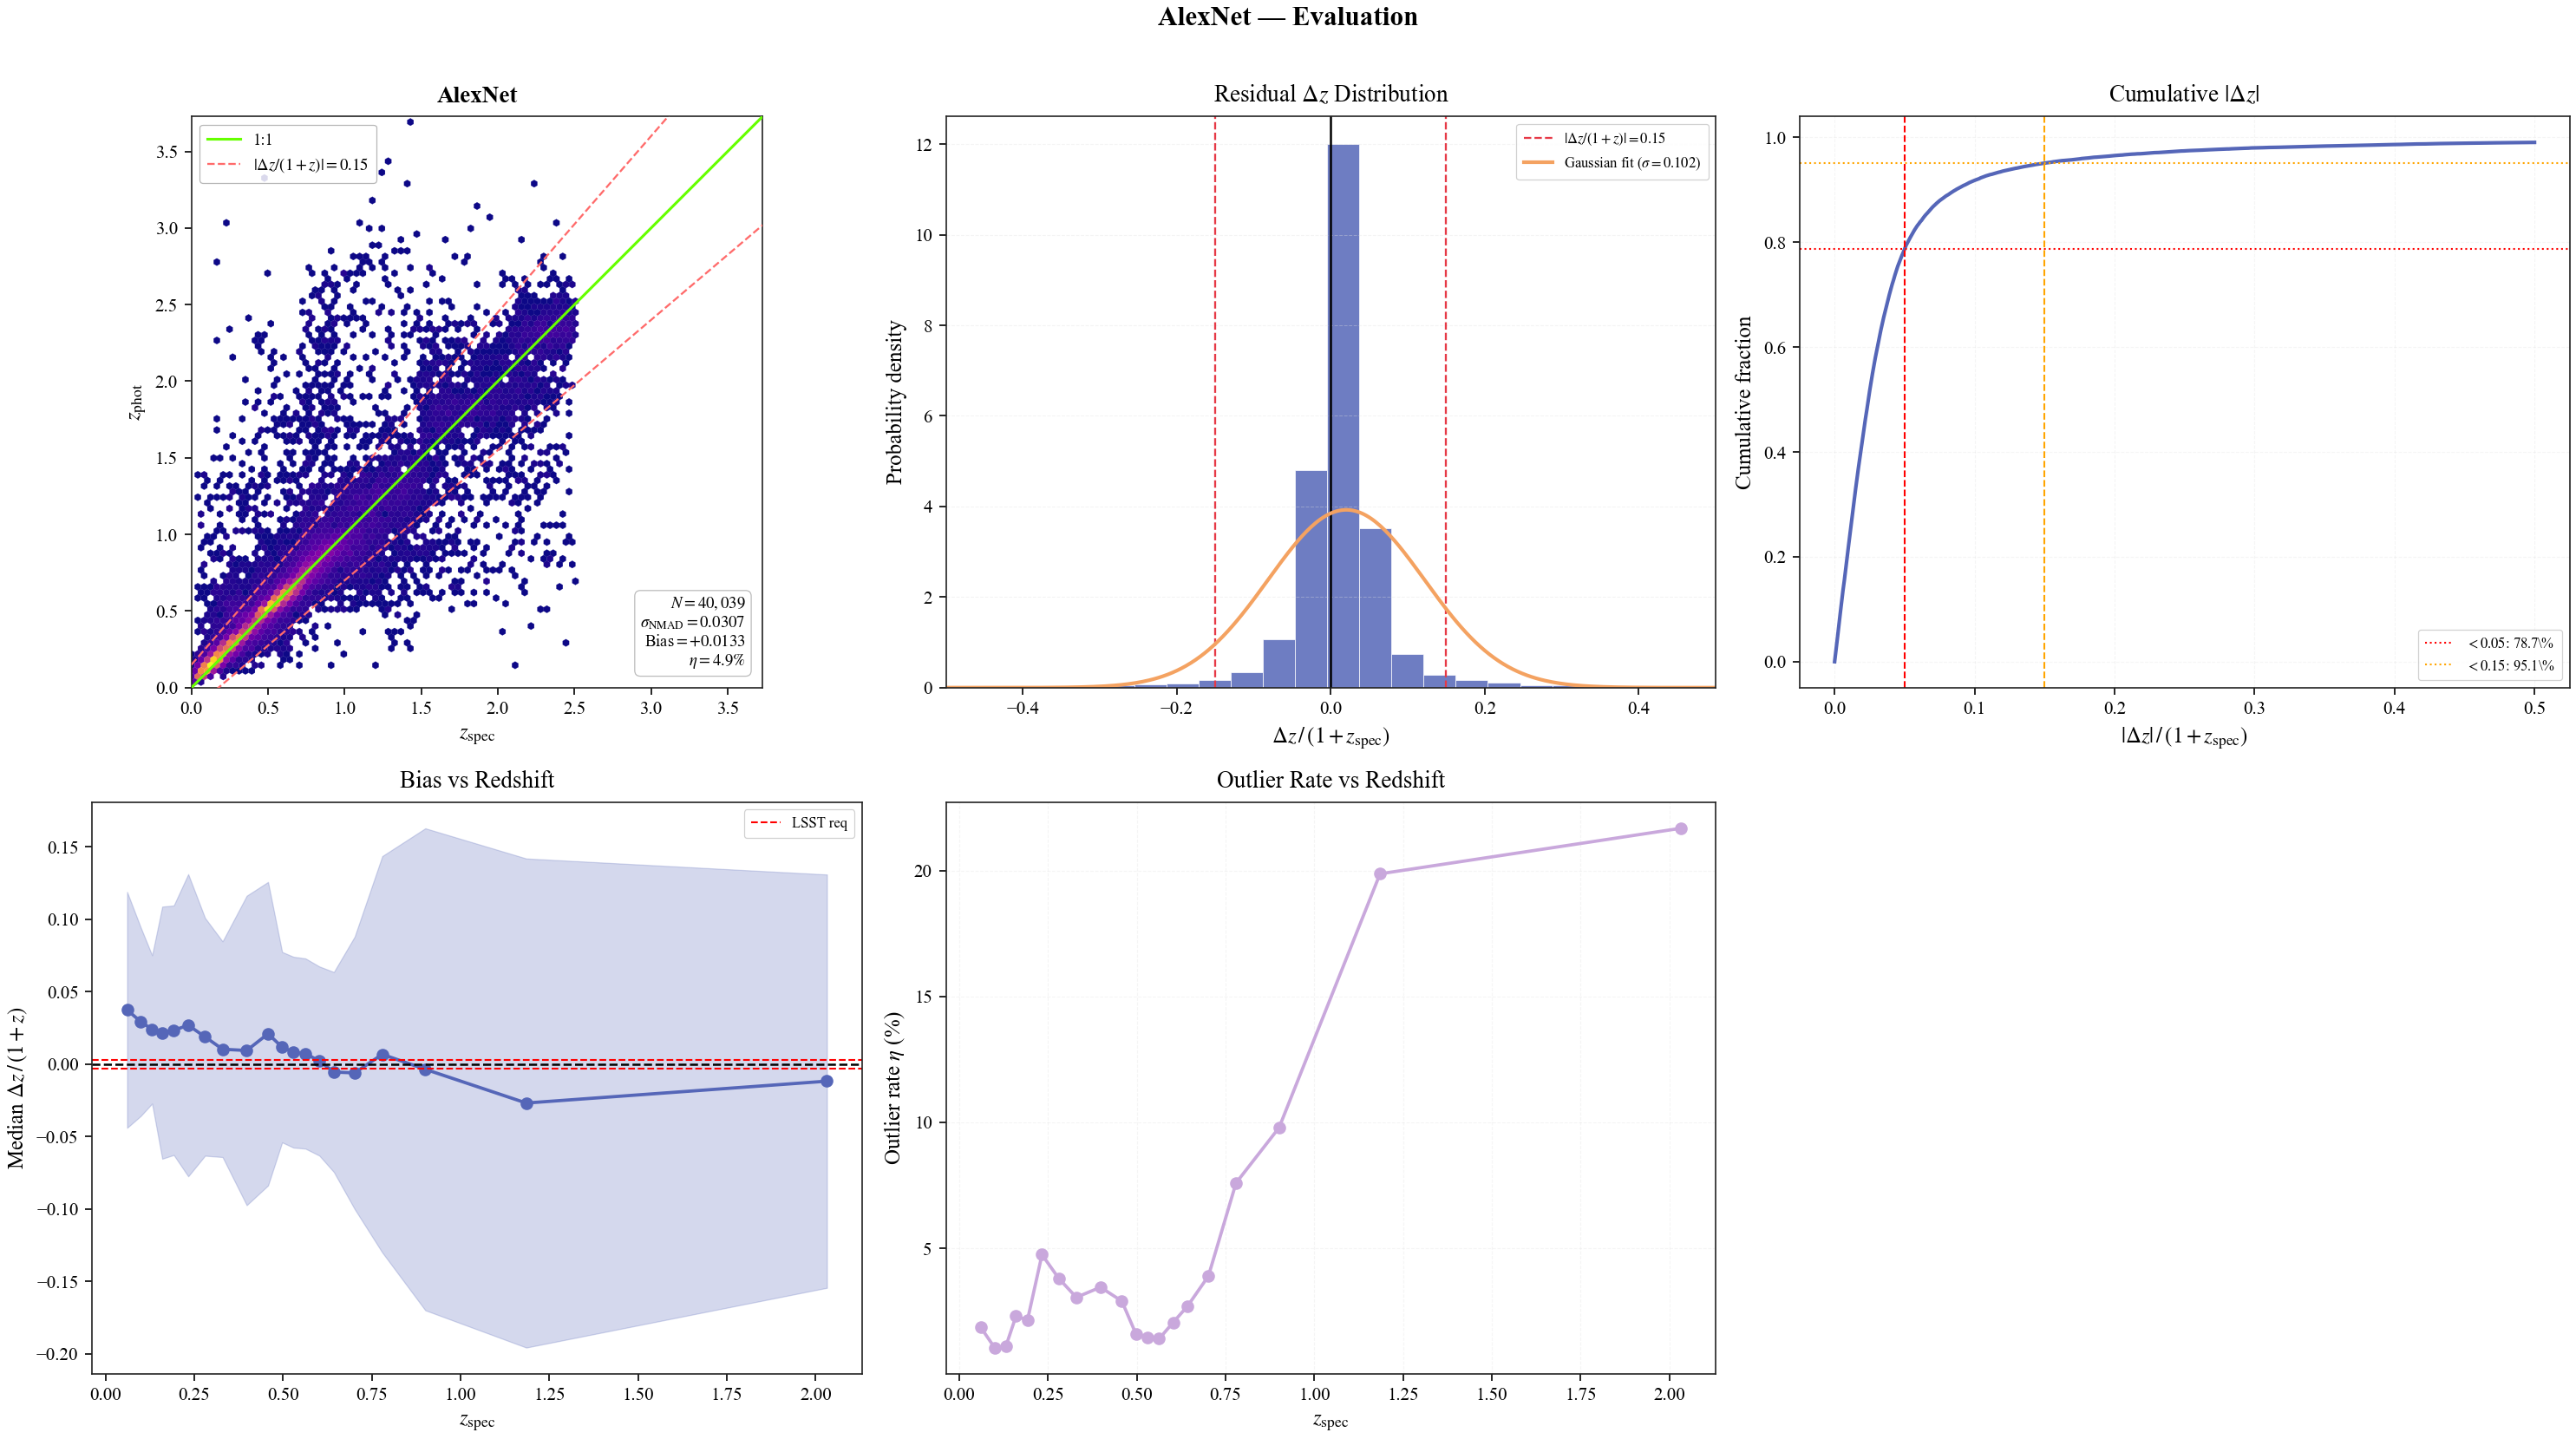

In [22]:
full_evaluation(
    name="AlexNet",
    y_true=y_true_primary,
    y_pred=y_pred_primary,
    save_path=os.path.join(BASE_REPORTS, "alexnet_full_eval.png"),
)